In [17]:
import pandas as pd

In [18]:
df = pd.read_csv('data/cicids2017_cleaned.csv')

In [19]:
df.shape
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,...,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,Attack Type
0,22,1266342,41,2664,456,0,64.975610,109.864573,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
1,22,1319353,41,2664,456,0,64.975610,109.864573,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
2,22,160,1,0,0,0,0.000000,0.000000,0,0,...,243,0,32,0.0,0,0,0.0,0,0,Normal Traffic
3,22,1303488,41,2728,456,0,66.536585,110.129945,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
4,35396,77,1,0,0,0,0.000000,0.000000,0,0,...,290,0,32,0.0,0,0,0.0,0,0,Normal Traffic


In [20]:
df = df.sample(frac=0.5, random_state=42)

In [21]:
df.columns


Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Length of Fwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd Header Length', 'Bwd Header Length',
       'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length',
       'Max Packet Length', 'Packet Length Mean', 'Packet Length Std',
       'Packet Length Variance', 'FIN Flag Count', 'PSH Flag Count',
       'ACK Flag Count', 'Average Packet Size', 'Subflow Fwd Bytes',
       'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_p

In [22]:
df = df[df['Attack Type'] == 'Normal Traffic'].drop(columns=['Attack Type'])

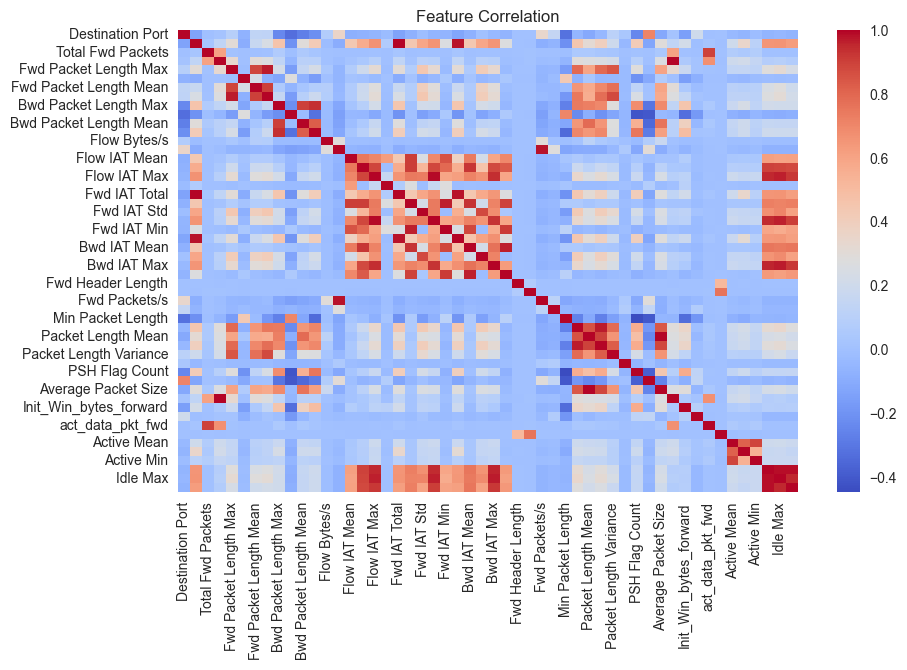

In [24]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

In [25]:
import numpy as np

corr_matrix = df.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

df = df.drop(columns=to_drop)

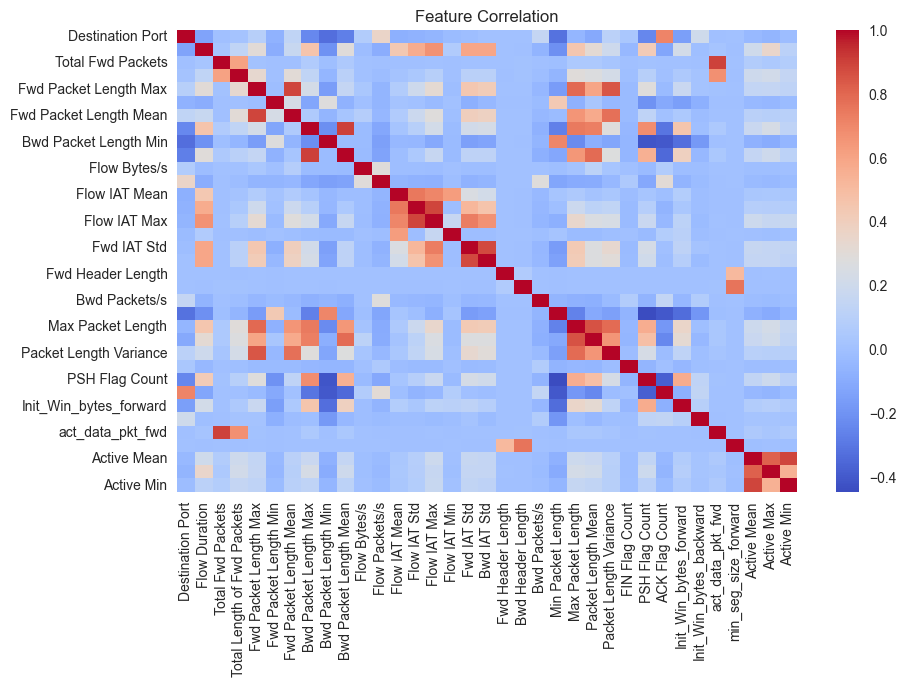

In [26]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

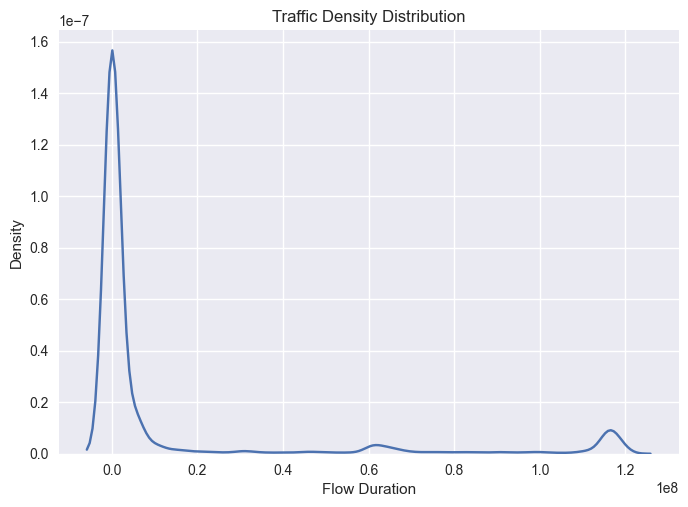

In [27]:

sns.kdeplot(df['Flow Duration'])
plt.title("Traffic Density Distribution")
plt.show()

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [30]:
# from sklearn.ensemble import IsolationForest

# model = IsolationForest(contamination=0.02, random_state=42)
# model.fit(X_train_scaled)
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.02, random_state=42)
df['anomaly'] = model.fit_predict(X_scaled)
df['anomaly'] = df['anomaly'].map({1:0, -1:1})

In [34]:
df_sample = df.sample(5000, random_state=42)

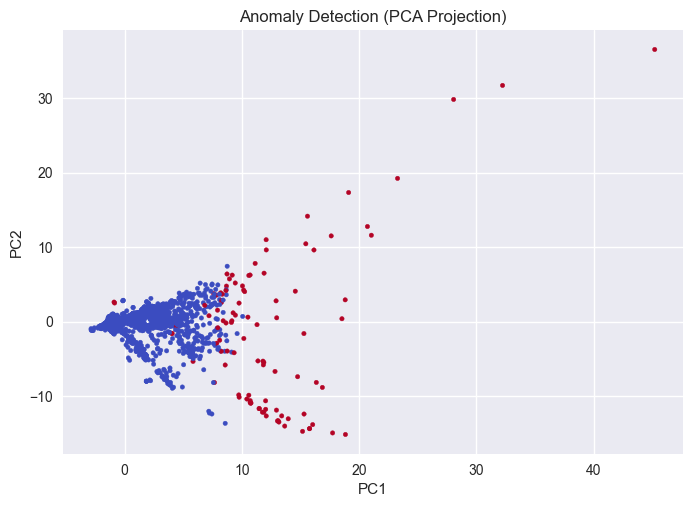

In [35]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

X = df_sample.drop(columns=['anomaly'])
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], 
            c=df_sample['anomaly'], 
            cmap='coolwarm', 
            s=10)

plt.title("Anomaly Detection (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [ ]:

mean_diff = df.groupby('anomaly').mean()

diff = (mean_diff.loc[1] - mean_diff.loc[0]).abs()

top_features = diff.sort_values(ascending=False).head(10)


Flow Duration             6.267825e+07
Flow IAT Max              3.953206e+07
Fwd IAT Std               1.375308e+07
Bwd IAT Std               1.171113e+07
Flow IAT Std              7.851390e+06
Flow Bytes/s              4.021390e+06
Active Max                2.463485e+06
Packet Length Variance    2.454210e+06
Flow IAT Mean             1.712224e+06
Active Mean               1.491723e+06
dtype: float64


In [37]:
top2 = top_features.index[:2]

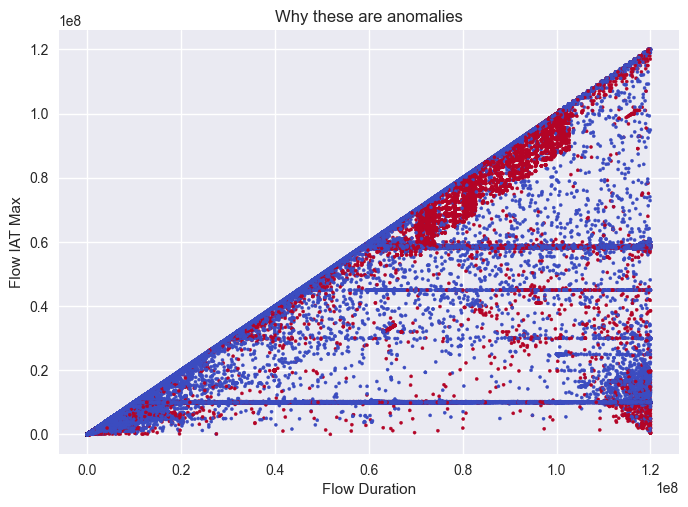

In [38]:

plt.scatter(df[top2[0]], df[top2[1]], c=df['anomaly'], s=5, cmap='coolwarm')
plt.xlabel(top2[0])
plt.ylabel(top2[1])
plt.title("Why these are anomalies")
plt.show()